## Portfolioaufgabe PA 3
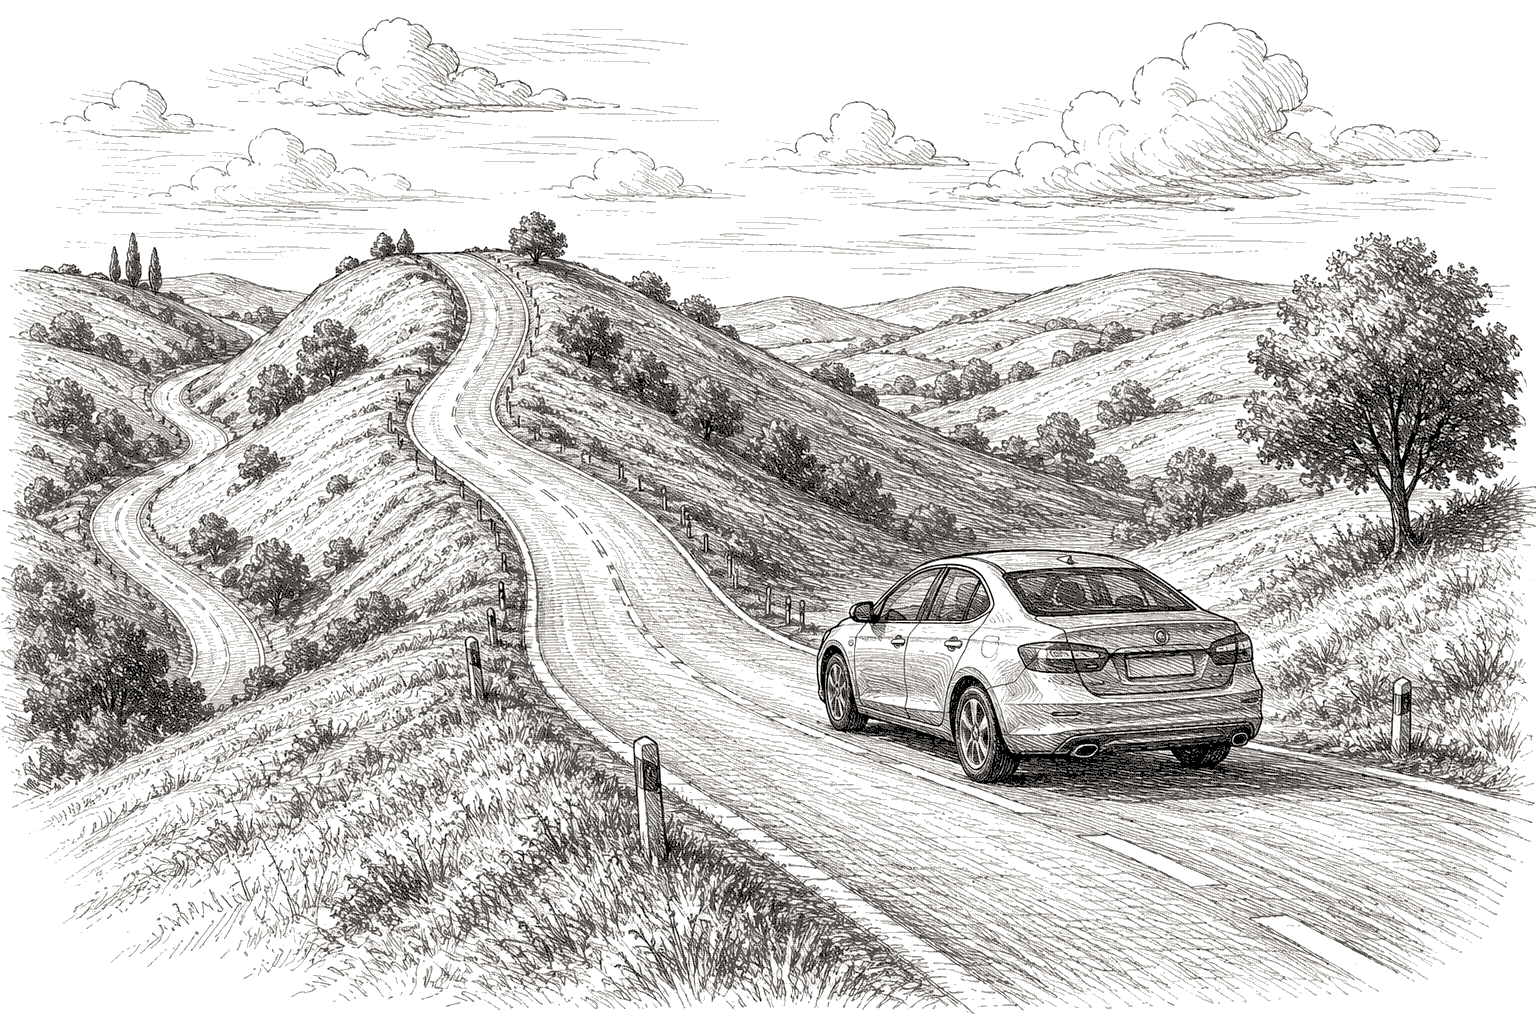

### Geschwindigkeitsregelung eines Fahrzeugs (Tempomat, Cruise Control)

Ein Fahrzeug soll mit konstanter Geschwindigkeit fahren. Die Straße enthält Steigungen und Gefälle. Ziel ist es, mit Python ein einfaches Fahrzeugmodell zu simulieren und einen PID-Regler zu entwickeln, der die Geschwindigkeit möglichst konstant hält.

Die Fahrzeugbewegung wird durch eine Kräftebilanz beschrieben, die Kräfte durch den Antrieb, den Rollwiderstand, den aerodynamischen Luftwiderstand sowie durch Steigungen oder Gefälle betrachtet. 

$$
m \frac{dv}{dt} =
F_\text{trac}
- F_\text{Roll}
- F_\text{Luft}
- F_\text{Steigung}
$$

mit:

\begin{gather*}
F_\text{trac}(u)=u(t) F_\text{max}, \qquad F_\text{Roll}=c_rmg,\\
F_\text{Luft}=\frac{1}{2}\rho c_w A v(t)^2, \qquad F_\text{Steigung}=mg\sin(\alpha(x))
\end{gather*}

Für kleine Steigungswinkel $\alpha$ gilt näherungsweise: 
$$
\sin(\alpha)\approx \tan(\alpha)=\frac{\text{Steigung in \%}}{100}=s
$$

Die Antriebskraft hängt von der Stellgröße $u(t)\in[-0.2,1]$ (Stellung des "Gaspedals") ab. Für positive Werte wird beschleunigt, für negative Werte wird rekuperativ gebremst, das heißt die kinetische Energie der Fahrzeugbewegung wird zurückgewonnen und zur Aufladung der Antriebsbatterie eingesetzt. Die bei positivem $u$ eingesetzte Antriebsleistung ist
$$
P_\text{trac}(u)= \eta u(t) F_\text{max} v(t).
$$

Folgende Parameter sollen für die Berechnungen verwendet werden
| Größe | Bedeutung | Wert |
|---|---|---|
| $m$ | Fahrzeugmasse | $1800\,kg$ |
| $g$ | Erdbeschleunigung | $9.81\,m/s^2$ |
| $F_\text{max}$ | maximale Antriebskraft | $4000\,N$ |
| $c_r$ | Rollwiderstandskoeffizient | $0.015$ |
| $\rho$ | Luftdichte | $1.225\,kg/m^3$ |
| $c_w$ | Luftwiderstandsbeiwert | $0.32$ |
| $A$ | Stirnfläche | $2.2\,m^2$ |
| $v_\text{soll}$ | Sollgeschwindigkeit | $25\,m/s$ |
| $\Delta t$ | Zeitschritt | $0.1\,s$ |
| $t_\text{max}$ | Simulationsdauer | $300\,s$ |
| $\eta$ | Wirkungsgrad des Antriebs | $0.85$ |

---
Zunächst soll die Beschleunigung $a(t)=\frac{dv}{dt}$ des Fahrzeugs ermittelt werden. Schreiben Sie eine Funktion `beschleunigung(v, s, u)`, mit der die Beschleunigung des Fahrzeugs zu einem Zeitpunkt mit bekanntem $v$, $s$ und $u$ ermittelt werden kann. 

Berechnen Sie die Beschleunigung für folgenden Fälle und speichern Sie die Ergebnisse in der Liste `a_erg`:
| Fall | $v$ | $s$ | $u$ |
|------|------|------|------|
| Ebene   | $20\,m/s$ | $0.0$ ($0$%)| $0.4$ |
| Steigung   | $25\,m/s$ | $0.04$ ($4$%) | $0.5$ |
| Gefälle   | $30\,m/s$ | $-0.03$ ($-3$%) | $-0.2$ |

Geben Sie die Werte in der Liste ebenfalls aus.

In [2]:
# notwenige imports für Aufgabe
import numpy as np
import matplotlib.pyplot as plt

# Fahrzeugparameter
m = 1800                 # kg
g = 9.81                 # m/s^2
F_max = 4000             # N
c_r = 0.015
rho = 1.225              # kg/m^3
c_w = 0.32
A = 2.2                  # m^2
eta = 0.85

# für Ergebnisse
a_erg = []

def beschleunigung(v, s, u):
# Hier eigenen Code schreiben ...
    F_trac = u * F_max
    F_luft = 1/2*rho*c_w*A*v**2
    F_roll = c_r*m*g
    F_steigung = m*g*s
    a = (F_trac - F_roll - F_luft - F_steigung)/m
    return a

a_erg.append(beschleunigung(20, 0, 0.4))
a_erg.append(beschleunigung(25, 0.04, 0.5))
a_erg.append(beschleunigung(30, -0.03, -0.2))

print(a_erg)

[0.6459166666666667, 0.42183888888888893, -0.5128944444444443]


In [3]:
# Hier sind Plausibilitäts-Tests:
assert callable(beschleunigung)
assert np.isclose(beschleunigung(20, 0, 0.4), 0.65, atol=1e-2)
assert np.isclose(beschleunigung(25, 0.04, 0.5), 0.42, atol=1e-2)
assert np.isclose(beschleunigung(30, -0.03, -0.2), -0.51, atol=1e-2)


Das Geländeprofil sei durch die zurückgelegte Strecke $x$ gegeben:

| Streckenabschnitt | Steigung $s$|
|---|---:|
| $0 \le x < 1000\,m$ | $+3\%$ |
| $1000 \le x < 1800\,m$ | $+5\%$ |
| $1800 \le x < 3000\,m$ | $-7\%$ |
| $3000 \le x < 3500\,m$ | $+6\%$ |
| $x \ge 3500\,m$ | $0\%$ |

Implementieren Sie eine Python-Funktion `steigung(x)`, die die Steigung $s$ für einen gegebenen Wert von $x$ zurückgibt. Stellen Sie mithilfe der Bibliothek `matplotlib` in einem Diagramm die Steigung $s$ über der Strecke $x \in [0, 4000]\,m$ in Schritten $dx = 10\,m$ dar. Beschriften Sie die Achsen und geben Sie dem Diagramm einen Titel!

_Lösungshinweis: Schreiben Sie die Funktion so, dass auch numpy-Arrays als Eingabe akzeptiert werden._  

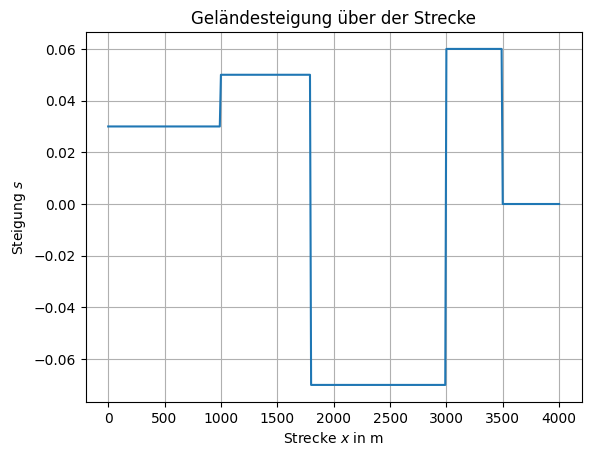

In [8]:
dx = 10

def steigung(x):
# Hier eigenen Code schreiben ...
    x = np.asarray(x)
    if np.any(x < 0):
        raise ValueError('x muss >= 0 sein')
    bedingungen = [x < 1000, x < 1800, x < 3000, x < 3500]
    werte       = [0.03,     0.05,     -0.07,    0.06]
    return np.select(bedingungen, werte, default=0.0)

# Diagramm: Steigung über der Strecke
x_plot = np.arange(0, 4000 + dx, dx)
plt.figure()
plt.plot(x_plot, steigung(x_plot))
plt.xlabel('Strecke $x$ in m')
plt.ylabel('Steigung $s$')
plt.title('Geländesteigung über der Strecke')
plt.grid(True)
plt.show()

In [5]:
# Hier sind Plausibilitäts-Tests:
assert callable(steigung)
assert np.isclose(steigung(500), 0.03)
assert np.isclose(steigung(1500), 0.05)
assert np.isclose(steigung(2500), -0.07)
assert np.isclose(steigung(3200), 0.06)
assert np.isclose(steigung(4000), 0.0)

Stellen Sie nun in einem weiteren Diagramm das Geländeprofil $h(x)$ dar. Berechnen Sie dazu die Variable `h` als Numpy-Array, indem Sie die Steigung $s$ über der Strecke $x$ durch Aufsummieren integrieren. Beschriften Sie die Achsen und geben Sie dem Diagramm einen Titel! Gehen Sie davon aus, dass $h(0)=0$ gilt!

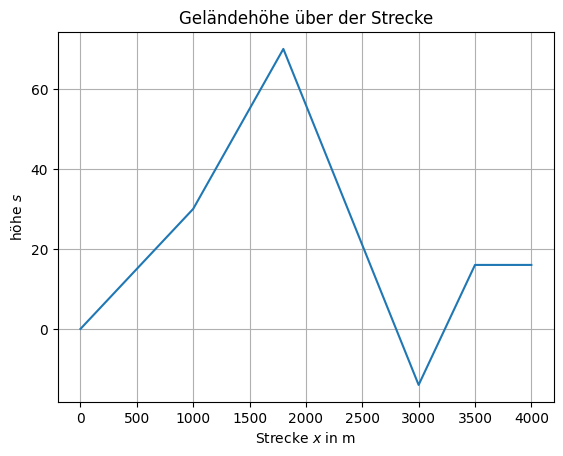

In [12]:
# Hier eigenen Code schreiben ...
h = np.array([0])

x_max = 4000

x = np.arange(0, x_max + dx, dx)
h = np.concatenate(([0.0], np.cumsum(steigung(x[:-1]) * dx)))

# Diagramm: Steigung über der Strecke
x_plot = np.arange(0, 4000 + dx, dx)
plt.figure()
plt.plot(x_plot, h)
plt.xlabel('Strecke $x$ in m')
plt.ylabel('höhe $s$')
plt.title('Geländehöhe über der Strecke')
plt.grid(True)
plt.show()


In [13]:
# Hier sind Plausibilitäts-Tests:
assert isinstance(h, np.ndarray)
assert len(h) == len(x)
assert h[-1] > 0 

Simulieren Sie die Fahrt des Fahrzeugs ohne Regler mit konstantem Stellsignal $u$. Verwenden Sie dazu das explizite Euler-Verfahren, bei dem die Geschwindigkeit $v$ und die zurückgelegte Strecke $x$ in diskreten Zeitschritten aus den Werten für den vorhergehenden Zeitpunkt berechnet werden:

\begin{align*}
v_{k+1}=v_k+\Delta t\cdot a_k\\
x_{k+1}=x_k+\Delta t\cdot v_k
\end{align*}

und schreiben Sie eine Funktion `simulation(va, xa, k, u)`, die die Simulation für ein gegebenes Stellsignal $u$ und einen Zeitschritt durchführt. Dabei sind $va$ und $xa$ die Arrays, in denen die Werte für Geschwindigkeit und Strecke gespeichert werden, und $k$ der aktuelle Zeitschritt. $u$ ist die Stellgröße, die für die Berechnung der Beschleunigung verwendet wird. Die Funktion gibt keine werte zurück, sondern aktualisiert die Arrays `va` und `xa` an der Stelle `k+1` mit den neuen Werten für Geschwindigkeit und Strecke.

Starten Sie anschließend die Simulation mit $v(0)=0\,m/s$ und $x(0)=0\,m$. Legen Sie dazu die Arrays $v$ und $x$ an und berechnen Sie die Geschwindigkeit $v(t)$ und die zurückgelegte Strecke $x(t)$ für die Dauer der Simulation. Nehmen Sie zunächst $u=0.25$ an und wiederholen Sie die Simulation für $u=0.3$ und $u=0.35$. Verwenden Sie die oben angegebenen Werte für $\Delta t$ und $t_\text{max}$. Stellen Sie die Ergebnisse in einem Diagramm dar, in dem $v(t)$ über der Zeit $t$ dargestellt wird. Beschriften Sie die Achsen und geben Sie dem Diagramm einen Titel und eine Legende! 

Ermitteln Sie außerdem die Endgeschwindigkeit $v(t_\text{max})$, die zurückgelegte Strecke $x(t_\text{max})$ und die maximal erreichte Antriebsleistung $P_\text{trac}$ für die drei Fälle und speichern Sie diese in den Listen `v_end`, `x_end` und `P_max` (Einheiten m/s, m und W). Geben Sie diese Listen am Ende aus!

In [ ]:
# Simulationsparameter
dt = 0.1
t_max = 300
# Zeitvektor
t = np.arange(0, t_max + dt, dt)
# Listen für Ergebnisse
v_end = []
x_end = []
P_max = []

def simulation(va, xa, k, u):
# Hier eigenen Code schreiben ...


In [ ]:
# Hier sind Plausibilitäts-Tests:
assert callable(simulation)
_v = np.zeros(3); _x = np.zeros(3); _v[0] = 20.0; dt = 0.1
assert simulation(_v, _x, 0, 0.3) is None 
assert _v[1] != 0.0 and _x[1] != 0.0        
assert np.isclose(_x[1], 2.0)             

Die Geschwindigkeit soll mit einem P-Regler geregelt werden. Berechnen Sie dazu die **Regelabweichung** $e(t)$ als Differenz zwischen der Sollgeschwindigkeit $v_\text{soll}$ und der aktuellen Geschwindigkeit $v(t)$:
$$e(t)=v_\mathrm{soll}-v(t)$$
Daraus ergibt sich die **Stellgröße** $u(t)$ als Produkt aus der Regelabweichung $e(t)$ und einem Proportionalitätsfaktor $K_P$:
$$u(t)=K_P e(t)$$
Die minimale und maximale Stellgröße sind durch die Grenzen für $u$ gegeben, das heißt $u(t)$ muss in dem Intervall $[-0.2,1]$ liegen. 

Integrieren Sie den P-Regler in die Simulation, sodass die Stellgröße $u$ für jeden Zeitschritt automatisch aus der aktuellen Regelabweichung berechnet wird. Starten Sie die Simulation mit $v(0)=25\,m/s$, $x(0)=0\,m$ und probieren Sie verschiedene Proportionalitätsfaktoren von $K_P=0.05$, $K_P=0.1$ und $K_P=0.2$ aus. Berechnen Sie die Geschwindigkeit $v(t)$ und die zurückgelegte Strecke $x(t)$ für die Dauer der Simulation. Stellen Sie die Ergebnisse in mehreren untereinander dargestellten Diagrammen für verschiedene Größen dar:
-  $v(t)$ über der Zeit $t$ einschließlich der Sollgeschwindigkeit $v_\text{soll}$ als Referenz
-  $e(t)$ über der Zeit $t$
-  $u(t)$ über der Zeit $t$

Jedes Diagramm soll dabei drei Kurven für die verschiedenen Werte von $K_P$ enthalten.

Beschriften Sie die Achsen und geben Sie den Diagrammen Titel und eine Legende! 

In [ ]:
vsoll = 25.0  # m/s
# Diagramme
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Hier eigenen Code schreiben ...


Um die Regelgüte zu verbessern, soll die Regelung um einen Integral- und einen Differenzial-Anteil erweitert werden, für die auch die zeitlich integrierte und zeitlich differenzierte Regelabweichung berücksichtigt wird. Die Stellgröße $u(t)$ ergibt sich dann aus der Summe der drei Anteile:

\begin{align*}
u_k &= K_p e_k + K_I I_k + K_D D_k\\
I_k &=I_{k-1}+e_k \Delta t\\
D_k &= \frac{e_k-e_{k-1}}{\Delta t}\\
\end{align*}

| Variante | $K_p$ | $K_I$ | $K_D$ |
| -------- | ----: | ----: | ----: |
| A        |  0.10 | 0.005 |     0 |
| B        |  0.10 | 0.010 |  0.02 |
| C        |  0.15 | 0.015 |  0.05 |

Führen Sie die Simulation mit den drei Varianten durch und stellen Sie die Ergebnisse so wie zuvor in mehreren untereinander dargestellten Diagrammen für verschiedene Größen dar:
-  $v(t)$ über der Zeit $t$ einschließlich der Sollgeschwindigkeit $v_\text{soll}$ als Referenz
-  $e(t)$ über der Zeit $t$
-  $u(t)$ über der Zeit $t$

Beschriften Sie die Achsen und geben Sie den Diagrammen Titel!

In [ ]:
# Varianten
varianten = {'A': (0.1, 0.005, 0), 'B': (0.1, 0.010, 0.02), 'C': (0.15, 0.015, 0.05)}

# Hier eigenen Code schreiben ...


Mit dem Modell lassen sich nun weitere Fragen beantworten:

- Wie verhält sich die Regelung bei plötzlichen äußeren Einflüssen (Wind, Änderung der Sollgeschwindigkeit)?
- Wieviel Energie wird bei welcher Regelstrategie verbraucht?
- Lässt sich die Regelung auch erfolgreich durchführen, wenn nicht die Antriebskraft, sondern die Antriebsleistung begrenzt ist (das ist realistischer)?

Diese und weitere Fragen sollen im Rahmen der PA 3 jedoch nicht weiter verfolgt werden.